In [11]:
# ============================================================
# Isolation Forest anomaly detection on US500 from TradingView
# Exchange: CAPITALCOM
# Symbol: US500
# Timeframe: Daily
# Data used: last 3000 trading days
# Train: first 1500 observations
# Test: most recent 1500 observations
# Plot: US500 closing price during test period with anomaly markers
# ============================================================

# -----------------------------
# 1. Install missing libraries
# -----------------------------
# tvDatafeed is not always pre-installed in Jupyter environments.
# If you already have it installed, this cell will continue normally.
# If installation fails, run the pip command manually in a notebook cell:
# !pip install tvDatafeed

import sys
import subprocess
import importlib.util

def install_if_missing(package_name, import_name=None):
    """
    Small helper function to install a package only if it is missing.
    package_name: name used by pip
    import_name: name used by Python import
    """
    if import_name is None:
        import_name = package_name

    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

install_if_missing("tvDatafeed", "tvDatafeed")
install_if_missing("plotly", "plotly")
install_if_missing("scikit-learn", "sklearn")

# -----------------------------
# 2. Import libraries
# -----------------------------

import numpy as np
import pandas as pd

from tvDatafeed import TvDatafeed, Interval
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import plotly.graph_objects as go


# -----------------------------
# 3. Download TradingView data
# -----------------------------
# This initializes tvDatafeed without login.
# In many cases, daily public data works without credentials.
# If your environment requires login, replace with:
# tv = TvDatafeed(username="YOUR_USERNAME", password="YOUR_PASSWORD")

tv = TvDatafeed()

# Pull last 3000 daily bars for CAPITALCOM:US500.
# TradingView symbol: US500
# TradingView exchange: CAPITALCOM
# Interval: daily
# Number of bars: 3000

df = tv.get_hist(
    symbol="US500",
    exchange="CAPITALCOM",
    interval=Interval.in_daily,
    n_bars=3000
)

# -----------------------------
# 4. Basic data validation
# -----------------------------

if df is None or df.empty:
    raise ValueError(
        "No data was returned from TradingView. "
        "Check whether tvDatafeed is working in your environment, "
        "and confirm that CAPITALCOM:US500 is available."
    )

# Keep only clean data.
# tvDatafeed usually returns columns:
# symbol, open, high, low, close, volume
df = df.copy()
df = df.dropna()

# Make sure the index is datetime and sorted from oldest to newest.
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Keep the last 3000 rows, in case the API returns more.
df = df.tail(3000)

if len(df) < 3000:
    print(f"Warning: only {len(df)} rows were returned. The model will still run, but not with full 3000 bars.")

# -----------------------------
# 5. Feature engineering
# -----------------------------
# Isolation Forest should not usually be trained only on raw price,
# because price has trend and scale effects.
#
# Instead, we create market-behavior features:
# - daily log return
# - absolute return
# - 5-day volatility
# - 20-day volatility
# - distance from 20-day moving average
# - distance from 50-day moving average
# - intraday range relative to close
#
# The model then detects unusual market states,
# not simply high or low prices.

df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["abs_return"] = df["log_return"].abs()

df["vol_5"] = df["log_return"].rolling(5).std()
df["vol_20"] = df["log_return"].rolling(20).std()

df["ma_20"] = df["close"].rolling(20).mean()
df["ma_50"] = df["close"].rolling(50).mean()

df["dist_ma_20"] = (df["close"] / df["ma_20"]) - 1
df["dist_ma_50"] = (df["close"] / df["ma_50"]) - 1

df["range_close"] = (df["high"] - df["low"]) / df["close"]

# Remove rows lost because of rolling calculations.
df_model = df.dropna().copy()

# -----------------------------
# 6. Enforce train/test split
# -----------------------------
# Because rolling indicators remove some initial rows,
# we need at least 3000 usable observations after feature construction
# if we want exactly 1500 train and 1500 test.
#
# If fewer than 3000 usable observations are available,
# we still keep the intended structure as much as possible:
# first half for training, second half for testing.

feature_cols = [
    "log_return",
    "abs_return",
    "vol_5",
    "vol_20",
    "dist_ma_20",
    "dist_ma_50",
    "range_close"
]

# Use the most recent 3000 usable rows after feature creation.
df_model = df_model.tail(3000)

if len(df_model) < 3000:
    print(
        f"Warning: after feature engineering, only {len(df_model)} usable rows remain. "
        "This happens because rolling features require historical observations."
    )

# Preferred split:
# 1500 rows for training, 1500 rows for testing.
# If fewer rows are available, split approximately in half.

if len(df_model) >= 3000:
    train_size = 1500
    test_size = 1500
    df_train = df_model.iloc[:train_size].copy()
    df_test = df_model.iloc[train_size:train_size + test_size].copy()
else:
    train_size = len(df_model) // 2
    df_train = df_model.iloc[:train_size].copy()
    df_test = df_model.iloc[train_size:].copy()

print(f"Training observations: {len(df_train)}")
print(f"Testing observations: {len(df_test)}")
print(f"Training period: {df_train.index.min().date()} to {df_train.index.max().date()}")
print(f"Testing period: {df_test.index.min().date()} to {df_test.index.max().date()}")

# -----------------------------
# 7. Prepare model inputs
# -----------------------------
# Scaling is not mandatory for Isolation Forest,
# but it is helpful when features have different numerical magnitudes.
# We fit the scaler only on the training set to avoid data leakage.

X_train = df_train[feature_cols].values
X_test = df_test[feature_cols].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 8. Fit Isolation Forest
# -----------------------------
# Important parameters:
#
# n_estimators:
# Number of trees in the forest.
#
# contamination:
# Expected proportion of anomalies in the data.
# Here we use 0.03, meaning roughly 3% of test observations may be flagged.
# You can change this depending on how selective you want the model to be.
#
# random_state:
# Makes the result reproducible.

iso_model = IsolationForest(
    n_estimators=500,
    contamination=0.05,
    random_state=42,
    max_samples="auto"
)

iso_model.fit(X_train_scaled)

# -----------------------------
# 9. Predict anomalies on test set
# -----------------------------
# Isolation Forest returns:
#  1 for normal observations
# -1 for anomalies

df_test["iforest_prediction"] = iso_model.predict(X_test_scaled)

# decision_function:
# Higher values = more normal
# Lower values = more anomalous

df_test["anomaly_score"] = iso_model.decision_function(X_test_scaled)

# Create a clean anomaly flag.
df_test["is_anomaly"] = df_test["iforest_prediction"] == -1

# Extract anomaly rows for plotting.
df_anomalies = df_test[df_test["is_anomaly"]].copy()

print(f"Detected anomalies in test set: {len(df_anomalies)}")
print(f"Anomaly rate in test set: {len(df_anomalies) / len(df_test):.2%}")

# -----------------------------
# 10. Plot with Plotly graph objects
# -----------------------------
# The main chart shows the US500 close price during the test period.
# Anomaly points are marked directly on the closing price line.

fig = go.Figure()

# Close price line
fig.add_trace(
    go.Scatter(
        x=df_test.index,
        y=df_test["close"],
        mode="lines",
        name="US500 Close",
        line=dict(width=2),
        hovertemplate=(
            "<b>Date</b>: %{x}<br>"
            "<b>Close</b>: %{y:.2f}<extra></extra>"
        )
    )
)

# Anomaly markers
fig.add_trace(
    go.Scatter(
        x=df_anomalies.index,
        y=df_anomalies["close"],
        mode="markers",
        name="Isolation Forest Anomaly",
        marker=dict(
            size=9,
            symbol="x"
        ),
        customdata=np.stack(
            [
                df_anomalies["anomaly_score"],
                df_anomalies["log_return"],
                df_anomalies["vol_20"],
                df_anomalies["dist_ma_20"]
            ],
            axis=-1
        ),
        hovertemplate=(
            "<b>Date</b>: %{x}<br>"
            "<b>Close</b>: %{y:.2f}<br>"
            "<b>Anomaly score</b>: %{customdata[0]:.4f}<br>"
            "<b>Log return</b>: %{customdata[1]:.4%}<br>"
            "<b>20D volatility</b>: %{customdata[2]:.4%}<br>"
            "<b>Distance from 20D MA</b>: %{customdata[3]:.2%}"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="US100 Isolation Forest for optimizing DCA, Test Set Only: om-qs.com",
    xaxis_title="Date",
    yaxis_title="US500 Close",
    template="plotly_white",
    width=1200,
    height=650,
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    )
)

fig.update_xaxes(
    rangeslider_visible=False,
    showgrid=True
)

fig.update_yaxes(
    showgrid=True
)

fig.show()

# -----------------------------
# 11. Optional: display anomaly table
# -----------------------------
# This lets you inspect the dates and market conditions flagged by the model.

anomaly_table = df_anomalies[
    [
        "close",
        "log_return",
        "vol_20",
        "dist_ma_20",
        "dist_ma_50",
        "range_close",
        "anomaly_score"
    ]
].copy()

display(anomaly_table.tail(20))

Training observations: 1475
Testing observations: 1476
Training period: 2014-12-23 to 2020-09-21
Testing period: 2020-09-22 to 2026-06-08
Detected anomalies in test set: 49
Anomaly rate in test set: 3.32%


,close,log_return,vol_20,dist_ma_20,dist_ma_50,range_close,anomaly_score
datetime,,,,,,,
2022-11-29 23:00:00,4086.5,0.032531,0.016660,0.038539,0.073596,0.036608,-0.061070
2024-12-17 23:00:00,5860.4,-0.031245,0.008109,-0.027660,-0.011173,0.041158,-0.014744
2025-04-02 23:00:00,5379.1,-0.029636,0.013553,-0.044718,-0.082252,0.027309,-0.001578
2025-04-03 23:00:00,5061.4,-0.060878,0.018604,-0.095520,-0.133390,0.070376,-0.161024
2025-04-07 00:00:00,5082.7,0.004199,0.018216,-0.087342,-0.126950,0.087985,-0.099484
2025-04-07 23:00:00,4978.0,-0.020814,0.018540,-0.101381,-0.141749,0.072238,-0.099194
2025-04-08 23:00:00,5478.0,0.095712,0.029277,-0.010132,-0.053697,0.116977,-0.202613
2025-04-09 23:00:00,5267.7,-0.039146,0.030440,-0.045879,-0.087524,0.072119,-0.152046
2025-04-10 23:00:00,5361.1,0.017575,0.030470,-0.026661,-0.069170,0.039283,-0.067420


In [12]:
# ============================================================
# Isolation Forest anomaly detection on US500 volatility
# Exchange: CAPITALCOM
# Symbol: US500
# Timeframe: Daily
# Data used: last 3000 trading days
# Train: first 1500 observations
# Test: most recent 1500 observations
# Plot: US500 realized volatility during test period with anomaly markers
# ============================================================

# -----------------------------
# 1. Install missing libraries
# -----------------------------
# tvDatafeed is not always pre-installed in Jupyter environments.
# If you already have it installed, this cell will continue normally.
# If installation fails, run the pip command manually in a notebook cell:
# !pip install tvDatafeed

import sys
import subprocess
import importlib.util

def install_if_missing(package_name, import_name=None):
    """
    Installs a package only if it is not already available in the environment.

    package_name: name used by pip
    import_name: name used by Python import
    """
    if import_name is None:
        import_name = package_name

    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

install_if_missing("tvDatafeed", "tvDatafeed")
install_if_missing("plotly", "plotly")
install_if_missing("scikit-learn", "sklearn")

# -----------------------------
# 2. Import libraries
# -----------------------------

import numpy as np
import pandas as pd

from tvDatafeed import TvDatafeed, Interval
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import plotly.graph_objects as go


# -----------------------------
# 3. Download TradingView data
# -----------------------------
# This initializes tvDatafeed without login.
# In many cases, daily public data works without credentials.
# If your environment requires login, replace with:
# tv = TvDatafeed(username="YOUR_USERNAME", password="YOUR_PASSWORD")

tv = TvDatafeed()

df = tv.get_hist(
    symbol="US500",
    exchange="CAPITALCOM",
    interval=Interval.in_daily,
    n_bars=3000
)

# -----------------------------
# 4. Basic data validation
# -----------------------------

if df is None or df.empty:
    raise ValueError(
        "No data was returned from TradingView. "
        "Check whether tvDatafeed is working in your environment, "
        "and confirm that CAPITALCOM:US500 is available."
    )

df = df.copy()
df = df.dropna()

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df = df.tail(3000)

if len(df) < 3000:
    print(f"Warning: only {len(df)} rows were returned. The model will still run, but not with full 3000 bars.")

# -----------------------------
# 5. Feature engineering
# -----------------------------
# The model will detect unusual market states using several market-behavior variables.
#
# The chart, however, will focus specifically on volatility.
#
# Volatility definition used for plotting:
# 20-day realized volatility, annualized.
#
# Formula:
# rolling 20-day standard deviation of daily log returns * sqrt(252)
#
# This gives a volatility estimate comparable to an annualized volatility number.

df["log_return"] = np.log(df["close"] / df["close"].shift(1))
df["abs_return"] = df["log_return"].abs()

df["vol_5"] = df["log_return"].rolling(5).std()
df["vol_20"] = df["log_return"].rolling(20).std()

df["realized_vol_20_ann"] = df["vol_20"] * np.sqrt(252)

df["ma_20"] = df["close"].rolling(20).mean()
df["ma_50"] = df["close"].rolling(50).mean()

df["dist_ma_20"] = (df["close"] / df["ma_20"]) - 1
df["dist_ma_50"] = (df["close"] / df["ma_50"]) - 1

df["range_close"] = (df["high"] - df["low"]) / df["close"]

# Remove rows lost because of rolling calculations.
df_model = df.dropna().copy()

# -----------------------------
# 6. Enforce train/test split
# -----------------------------
# We use the most recent 3000 usable rows after rolling calculations.
# The preferred split is:
# - first 1500 rows for training
# - most recent 1500 rows for testing

feature_cols = [
    "log_return",
    "abs_return",
    "vol_5",
    "vol_20",
    "dist_ma_20",
    "dist_ma_50",
    "range_close"
]

df_model = df_model.tail(3000)

if len(df_model) < 3000:
    print(
        f"Warning: after feature engineering, only {len(df_model)} usable rows remain. "
        "This happens because rolling features require historical observations."
    )

if len(df_model) >= 3000:
    train_size = 1500
    test_size = 1500

    df_train = df_model.iloc[:train_size].copy()
    df_test = df_model.iloc[train_size:train_size + test_size].copy()
else:
    train_size = len(df_model) // 2

    df_train = df_model.iloc[:train_size].copy()
    df_test = df_model.iloc[train_size:].copy()

print(f"Training observations: {len(df_train)}")
print(f"Testing observations: {len(df_test)}")
print(f"Training period: {df_train.index.min().date()} to {df_train.index.max().date()}")
print(f"Testing period: {df_test.index.min().date()} to {df_test.index.max().date()}")

# -----------------------------
# 7. Prepare model inputs
# -----------------------------
# Scaling avoids one feature dominating the anomaly model simply because
# it has larger numerical values.
#
# The scaler is fit only on the training set to avoid data leakage.

X_train = df_train[feature_cols].values
X_test = df_test[feature_cols].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 8. Fit Isolation Forest
# -----------------------------
# contamination controls how many observations the model is expected to flag.
#
# 0.03 means roughly 3 percent of the observations may be treated as anomalies.
# Reduce it to 0.01 for a stricter model.
# Increase it to 0.05 for a more sensitive model.

iso_model = IsolationForest(
    n_estimators=500,
    contamination=0.05,
    random_state=42,
    max_samples="auto"
)

iso_model.fit(X_train_scaled)

# -----------------------------
# 9. Predict anomalies on test set
# -----------------------------
# Isolation Forest returns:
#  1 for normal observations
# -1 for anomalies

df_test["iforest_prediction"] = iso_model.predict(X_test_scaled)

# Higher score means more normal.
# Lower score means more anomalous.

df_test["anomaly_score"] = iso_model.decision_function(X_test_scaled)
df_test["is_anomaly"] = df_test["iforest_prediction"] == -1

df_anomalies = df_test[df_test["is_anomaly"]].copy()

print(f"Detected anomalies in test set: {len(df_anomalies)}")
print(f"Anomaly rate in test set: {len(df_anomalies) / len(df_test):.2%}")

# -----------------------------
# 10. Plot volatility with Plotly graph objects
# -----------------------------
# Instead of plotting the close price, this chart plots:
# 20-day annualized realized volatility.
#
# The anomaly markers are placed on the volatility curve.
#
# Important interpretation:
# The model does not only detect high volatility.
# It detects unusual combinations of return, volatility, trend distance,
# and daily range. So an anomaly can appear during a volatility spike,
# a sharp return, a regime shift, or an unusual compression/expansion state.

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df_test.index,
        y=df_test["realized_vol_20_ann"],
        mode="lines",
        name="20D Realized Volatility, Annualized",
        line=dict(width=2),
        hovertemplate=(
            "<b>Date</b>: %{x}<br>"
            "<b>20D Realized Vol</b>: %{y:.2%}<extra></extra>"
        )
    )
)

fig.add_trace(
    go.Scatter(
        x=df_anomalies.index,
        y=df_anomalies["realized_vol_20_ann"],
        mode="markers",
        name="Isolation Forest Anomaly",
        marker=dict(
            size=9,
            symbol="x"
        ),
        customdata=np.stack(
            [
                df_anomalies["close"],
                df_anomalies["anomaly_score"],
                df_anomalies["log_return"],
                df_anomalies["realized_vol_20_ann"],
                df_anomalies["dist_ma_20"],
                df_anomalies["range_close"]
            ],
            axis=-1
        ),
        hovertemplate=(
            "<b>Date</b>: %{x}<br>"
            "<b>Close</b>: %{customdata[0]:.2f}<br>"
            "<b>Anomaly score</b>: %{customdata[1]:.4f}<br>"
            "<b>Log return</b>: %{customdata[2]:.4%}<br>"
            "<b>20D realized vol</b>: %{customdata[3]:.2%}<br>"
            "<b>Distance from 20D MA</b>: %{customdata[4]:.2%}<br>"
            "<b>Daily range / close</b>: %{customdata[5]:.2%}"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="US500 Isolation Forest Anomaly Detection on Volatility, Test Set Only",
    xaxis_title="Date",
    yaxis_title="20D Realized Volatility, Annualized",
    template="plotly_white",
    width=1200,
    height=650,
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    )
)

fig.update_xaxes(
    rangeslider_visible=False,
    showgrid=True
)

fig.update_yaxes(
    showgrid=True,
    tickformat=".0%"
)

fig.show()

# -----------------------------
# 11. Optional: display anomaly table
# -----------------------------
# This table helps you inspect which volatility states were flagged.

anomaly_table = df_anomalies[
    [
        "close",
        "realized_vol_20_ann",
        "log_return",
        "vol_5",
        "vol_20",
        "dist_ma_20",
        "dist_ma_50",
        "range_close",
        "anomaly_score"
    ]
].copy()

display(anomaly_table.tail(20))

Training observations: 1475
Testing observations: 1476
Training period: 2014-12-23 to 2020-09-21
Testing period: 2020-09-22 to 2026-06-08
Detected anomalies in test set: 49
Anomaly rate in test set: 3.32%


,close,realized_vol_20_ann,log_return,vol_5,vol_20,dist_ma_20,dist_ma_50,range_close,anomaly_score
datetime,,,,,,,,,
2022-11-29 23:00:00,4086.5,0.264472,0.032531,0.017751,0.016660,0.038539,0.073596,0.036608,-0.061070
2024-12-17 23:00:00,5860.4,0.128722,-0.031245,0.013859,0.008109,-0.027660,-0.011173,0.041158,-0.014744
2025-04-02 23:00:00,5379.1,0.215142,-0.029636,0.017039,0.013553,-0.044718,-0.082252,0.027309,-0.001578
2025-04-03 23:00:00,5061.4,0.295335,-0.060878,0.028208,0.018604,-0.095520,-0.133390,0.070376,-0.161024
2025-04-07 00:00:00,5082.7,0.289171,0.004199,0.027400,0.018216,-0.087342,-0.126950,0.087985,-0.099484
2025-04-07 23:00:00,4978.0,0.294316,-0.020814,0.023816,0.018540,-0.101381,-0.141749,0.072238,-0.099194
2025-04-08 23:00:00,5478.0,0.464754,0.095712,0.059519,0.029277,-0.010132,-0.053697,0.116977,-0.202613
2025-04-09 23:00:00,5267.7,0.483220,-0.039146,0.060751,0.030440,-0.045879,-0.087524,0.072119,-0.152046
2025-04-10 23:00:00,5361.1,0.483691,0.017575,0.051940,0.030470,-0.026661,-0.069170,0.039283,-0.067420


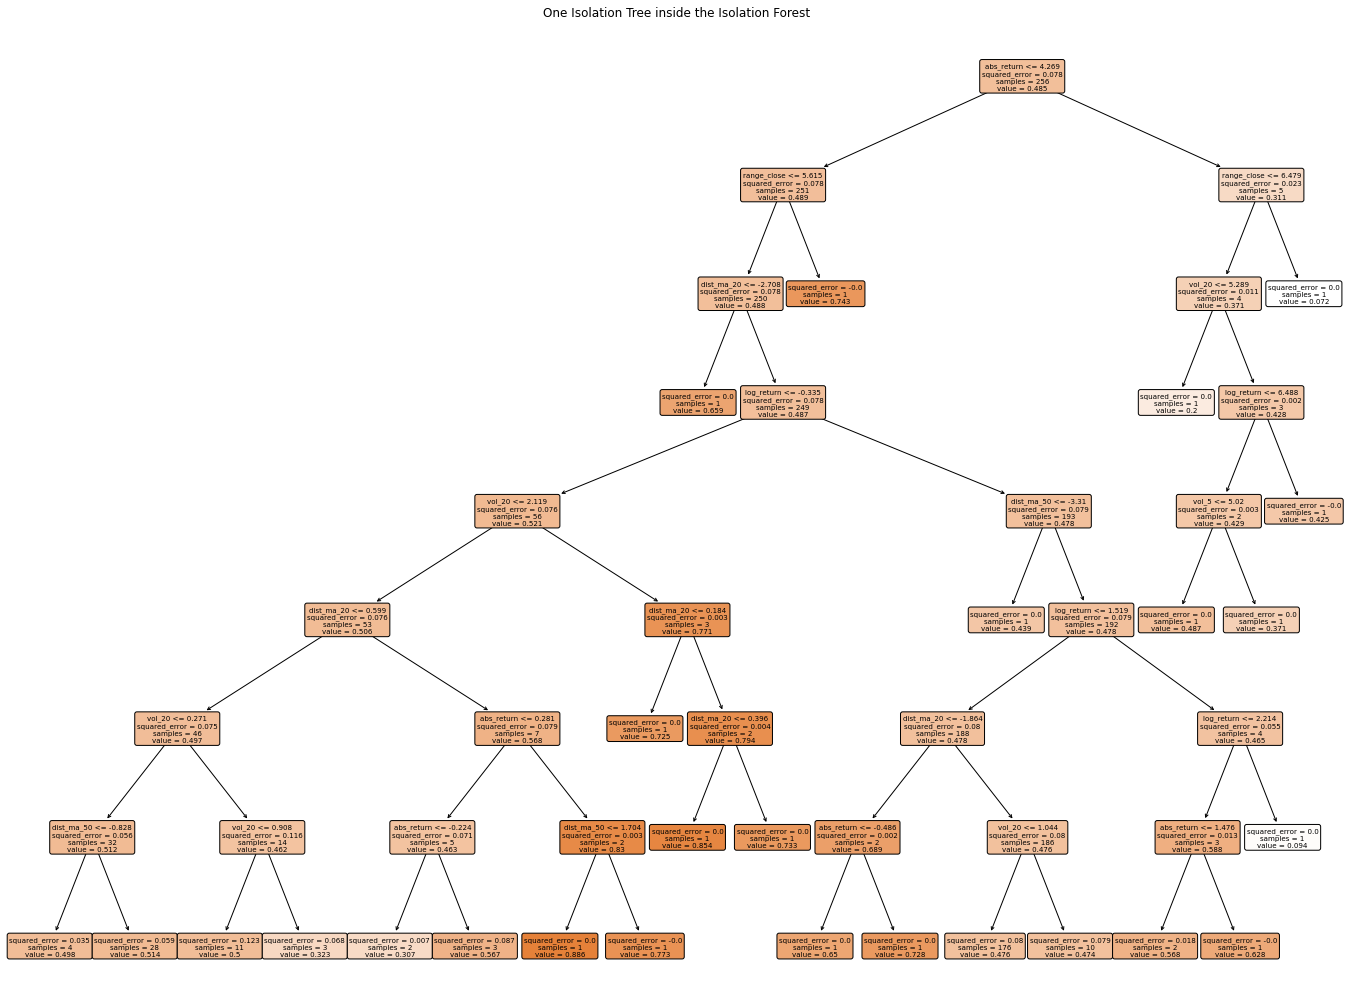

In [13]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Pick one tree from the Isolation Forest
tree_number = 0
one_tree = iso_model.estimators_[tree_number]

plt.figure(figsize=(24, 18))
plot_tree(
    one_tree,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    max_depth=20
)
plt.title("One Isolation Tree inside the Isolation Forest")
plt.show()